**APRENDIZAJE AUTOMÁTICO**


    GRUPO: CDDEIA-ELNO-4-2
    Docente: RODRIGUEZ MERCHÁN DARWIN ALEXANDER


Realizado por:

    ORTIZ LOPEZ JOHNNY AARON

**Importaciones necesarias**

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import (
    GridSearchCV,
    KFold,
    RandomizedSearchCV,
    cross_val_score,
    train_test_split,
)
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve
)

**Carga del dataset**

In [2]:
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df["target"] = data.target  # 0: Maligno, 1: Benigno

print("\nEstructura del Dataset")
print(f"Dimensiones: {df.shape[0]} filas y {df.shape[1]} columnas.\n")
print("Variables predictoras:", list(data.feature_names))

# Mostrar las primeras filas
df.head()


Estructura del Dataset
Dimensiones: 569 filas y 31 columnas.

Variables predictoras: [np.str_('mean radius'), np.str_('mean texture'), np.str_('mean perimeter'), np.str_('mean area'), np.str_('mean smoothness'), np.str_('mean compactness'), np.str_('mean concavity'), np.str_('mean concave points'), np.str_('mean symmetry'), np.str_('mean fractal dimension'), np.str_('radius error'), np.str_('texture error'), np.str_('perimeter error'), np.str_('area error'), np.str_('smoothness error'), np.str_('compactness error'), np.str_('concavity error'), np.str_('concave points error'), np.str_('symmetry error'), np.str_('fractal dimension error'), np.str_('worst radius'), np.str_('worst texture'), np.str_('worst perimeter'), np.str_('worst area'), np.str_('worst smoothness'), np.str_('worst compactness'), np.str_('worst concavity'), np.str_('worst concave points'), np.str_('worst symmetry'), np.str_('worst fractal dimension')]


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


**Variables globales**

In [3]:
# Apartado para variables globales
COL_OBJETIVO = "target"
columnas_predictoras = list(data.feature_names)

X_m = df[columnas_predictoras]
y_m = df[COL_OBJETIVO]

# Separación balanceada para clasificación (80% Entrenamiento, 20% Prueba)
X_train, X_test, y_train, y_test = train_test_split(
    X_m, y_m, test_size=0.2, random_state=1, stratify=y_m
)

print(
    f"Datos de entrenamiento: {X_train.shape[0]} | Datos de prueba: {X_test.shape[0]}"
)

Datos de entrenamiento: 455 | Datos de prueba: 114


**Entrenamiento e Interpretación de Métricas (Criterios 2, 3 y 4)**

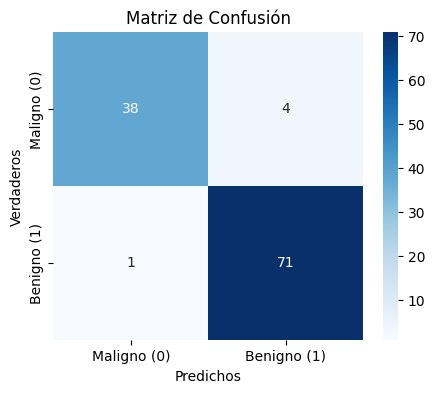

Evaluación del Modelo Base: 
MÉTRICA                   | RESULTADO      
-------------------------------------------
Exactitud (Accuracy)      | 0.9561         
Precisión (Precision)     | 0.9467         
Sensibilidad (Recall)     | 0.9861         
F1-Score                  | 0.9660         
AUC-ROC                   | 0.9940         


In [4]:
# 2. Entrenar un modelo de Regresión Logística
# Aumentar iteraciones (max_iter) para asegurar la convergencia del algoritmo
modelo_logistico = LogisticRegression(max_iter=10000, random_state=1)
modelo_logistico.fit(X_train, y_train)

# Predicciones de clases y probabilidades
pred_clase = modelo_logistico.predict(X_test)
pred_prob = modelo_logistico.predict_proba(X_test)[:, 1]

# 3. Generar e interpretar la Matriz de Confusión
matriz = confusion_matrix(y_test, pred_clase)

plt.figure(figsize=(5, 4))
sns.heatmap(
    matriz,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Maligno (0)", "Benigno (1)"],
    yticklabels=["Maligno (0)", "Benigno (1)"],
)
plt.title("Matriz de Confusión")
plt.ylabel("Verdaderos")
plt.xlabel("Predichos")
plt.show()

# 4. Calcular Precisión, Recall, F1-Score y AUC-ROC
print("Evaluación del Modelo Base: ")
print(f"{'MÉTRICA':<25} | {'RESULTADO':<15}")
print("-" * 43)
print(f"{'Exactitud (Accuracy)':<25} | {accuracy_score(y_test, pred_clase):<15.4f}")
print(f"{'Precisión (Precision)':<25} | {precision_score(y_test, pred_clase):<15.4f}")
print(f"{'Sensibilidad (Recall)':<25} | {recall_score(y_test, pred_clase):<15.4f}")
print(f"{'F1-Score':<25} | {f1_score(y_test, pred_clase):<15.4f}")
print(f"{'AUC-ROC':<25} | {roc_auc_score(y_test, pred_prob):<15.4f}")

    Curva ROC

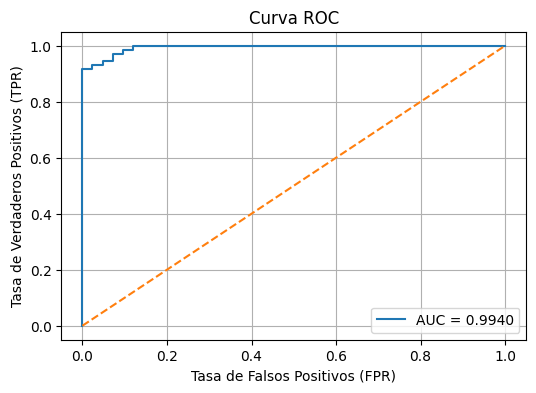

In [10]:
tasa_falsos_positivos, tasa_verdaderos_positivos, umbrales = roc_curve(y_test, pred_prob)

plt.figure(figsize=(6,4))
plt.plot(
    tasa_falsos_positivos,
    tasa_verdaderos_positivos,
    label=f"AUC = {roc_auc_score(y_test, pred_prob):.4f}"
)

plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("Tasa de Falsos Positivos (FPR)")
plt.ylabel("Tasa de Verdaderos Positivos (TPR)")
plt.title("Curva ROC")
plt.legend()
plt.grid(True)
plt.show()

**Validación Cruzada K-Fold (Criterio 5)**

In [5]:
# 5. Aplicar K-Fold Cross-Validation con k=5 y k=10
cv_5 = KFold(n_splits=5, shuffle=True, random_state=1)
cv_10 = KFold(n_splits=10, shuffle=True, random_state=1)

scores_k5 = cross_val_score(
    modelo_logistico, X_m, y_m, cv=cv_5, scoring="accuracy"
)
scores_k10 = cross_val_score(
    modelo_logistico, X_m, y_m, cv=cv_10, scoring="accuracy"
)

print("Comparación de Validación Cruzada (K-Fold):")
print(f"{'CONFIGURACIÓN':<15} | {'EXACTITUD PROMEDIO':<20} | {'DESVIACIÓN ESTÁNDAR':<20}")
print("-" * 63)
print(f"{'K = 5':<15} | {scores_k5.mean():<20.4f} | {scores_k5.std():<20.4f}")
print(f"{'K = 10':<15} | {scores_k10.mean():<20.4f} | {scores_k10.std():<20.4f}")

Comparación de Validación Cruzada (K-Fold):
CONFIGURACIÓN   | EXACTITUD PROMEDIO   | DESVIACIÓN ESTÁNDAR 
---------------------------------------------------------------
K = 5           | 0.9508               | 0.0263              
K = 10          | 0.9490               | 0.0337              


**Optimización de Hiperparámetros (Criterio 6)**

In [12]:
# 6. Optimizar hiperparámetros con GridSearchCV y RandomizedSearchCV
espacio_parametros = {
    "C": [0.001, 0.01, 0.1, 1, 10, 100],
    "penalty": ["l2"],  # l2 es compatible con el solver por defecto (lbfgs)
}

# Configurar las búsquedas
busqueda_grid = GridSearchCV(
    estimator=LogisticRegression(max_iter=10000, random_state=1),
    param_grid=espacio_parametros,
    cv=5,
    scoring="f1",
)
busqueda_random = RandomizedSearchCV(
    estimator=LogisticRegression(max_iter=10000, random_state=1),
    param_distributions=espacio_parametros,
    n_iter=4,
    cv=5,
    scoring="f1",
    random_state=1,
)

# Ajustar métodos de optimización
busqueda_grid.fit(X_train, y_train)
busqueda_random.fit(X_train, y_train)

print("Resultados de la Optimización:")
print(f"Mejores parámetros GridSearchCV: {busqueda_grid.best_params_}")
print(f"Mejor F1-Score Grid: {busqueda_grid.best_score_:.4f}\n")
print(f"Mejores parámetros RandomizedSearchCV: {busqueda_random.best_params_}")
print(f"Mejor F1-Score Random: {busqueda_random.best_score_:.4f}")

# Imprimir el tiempo total de procesamiento de cada búsqueda
print(f"Tiempo total GridSearchCV: {busqueda_grid.cv_results_['mean_fit_time'].sum():.4f} segundos")
print(f"Tiempo total RandomizedSearchCV: {busqueda_random.cv_results_['mean_fit_time'].sum():.4f} segundos")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

Resultados de la Optimización:
Mejores parámetros GridSearchCV: {'C': 10, 'penalty': 'l2'}
Mejor F1-Score Grid: 0.9596

Mejores parámetros RandomizedSearchCV: {'penalty': 'l2', 'C': 10}
Mejor F1-Score Random: 0.9596
Tiempo total GridSearchCV: 4.8432 segundos
Tiempo total RandomizedSearchCV: 3.6777 segundos


**Ajuste del Umbral de Decisión (Criterio 7)**

In [13]:
mejor_modelo = busqueda_grid.best_estimator_
probabilidades_test = mejor_modelo.predict_proba(X_test)[:, 1]

umbrales = [0.3, 0.5, 0.7]

# Listas para la gráfica
lista_precision = []
lista_recall = []
lista_f1 = []

print("Análisis de Impacto por Umbral de Decisión:")
print(f"{'UMBRAL':<8} | {'PRECISIÓN':<12} | {'RECALL (SENSIBILIDAD)':<22} | {'F1-SCORE':<12}")
print("-" * 62)

for umbral in umbrales:

    pred_personalizada = (probabilidades_test >= umbral).astype(int)

    p = precision_score(y_test, pred_personalizada)
    r = recall_score(y_test, pred_personalizada)
    f1 = f1_score(y_test, pred_personalizada)

    # Guardar para la gráfica
    lista_precision.append(p)
    lista_recall.append(r)
    lista_f1.append(f1)

    print(f"{umbral:<8} | {p:<12.4f} | {r:<22.4f} | {f1:<12.4f}")

Análisis de Impacto por Umbral de Decisión:
UMBRAL   | PRECISIÓN    | RECALL (SENSIBILIDAD)  | F1-SCORE    
--------------------------------------------------------------
0.3      | 0.9342       | 0.9861                 | 0.9595      
0.5      | 0.9467       | 0.9861                 | 0.9660      
0.7      | 0.9595       | 0.9861                 | 0.9726      


    Comparación por métrica

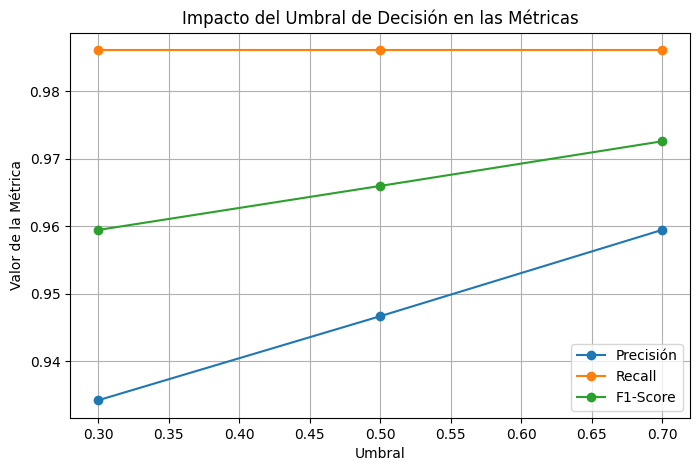

In [14]:
plt.figure(figsize=(8, 5))

plt.plot(
    umbrales,
    lista_precision,
    marker="o",
    label="Precisión"
)

plt.plot(
    umbrales,
    lista_recall,
    marker="o",
    label="Recall"
)

plt.plot(
    umbrales,
    lista_f1,
    marker="o",
    label="F1-Score"
)

plt.title("Impacto del Umbral de Decisión en las Métricas")
plt.xlabel("Umbral")
plt.ylabel("Valor de la Métrica")
plt.legend()
plt.grid(True)

plt.show()